# 1.5 Acoustic 2.5D, 3D, And Axisymmetric Simulations

This tutorial compares three acoustic geometry modes using the same simple two-layer material idea: 2.5D, full 3D, and 2D axisymmetric. Each section builds a project-owned simulation, defines mesh/boundaries/acquisition, and includes a result inspection path. The examples are intentionally small but complete.

By the end, you should be able to recognize which API pieces stay the same across geometry modes and which pieces change the coordinate interpretation of the same acoustic model.


## Geometry Modes

| Mode | Model geometry | Use case | Key API option |
| --- | --- | --- | --- |
| 2.5D | 2D x-depth cross-section with out-of-plane physics | Laterally invariant geology with 3D propagation effects | `dimension="2.5D"` |
| 3D | x-y-depth volume | Fully 3D acquisition or geology | `dimension=3`, `y_limits=[...]`, 3D coordinates |
| Axisymmetric | 2D radius-depth section | Cylindrical symmetry around an axis | `axisymmetric=True` and cylindrical global coordinate system |
| Fixed-axis 2D slice | 2D x-depth slice embedded in a 3D coordinate convention | Reusing 3D coordinate conventions for a 2D run | `CoordinateSystem.cartesian(..., fixed_axis="y", fixed_value=...)` |


## Imports


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
import frequensolve as fs

u = fs.ureg


## Shared Layer And Acquisition Helpers

The layer helper works for 2D, 2.5D, and 3D `LayeredModel` objects. The acquisition helpers keep each section focused on what changes between geometry modes.


In [2]:
def add_acoustic_layers(model):
    model.add_surface(name="top", depth=0.0 * u.km)
    model.add_layer(name="water", properties={"Vp": 1.5 * u.km / u.s, "Rho": 1.0 * u.g / u.cm**3})
    model.add_surface(name="interface", depth=0.25 * u.km)
    model.add_layer(name="basement", properties={"Vp": 2.4 * u.km / u.s, "Rho": 2.2 * u.g / u.cm**3})
    model.add_surface(name="bottom", depth=0.5 * u.km)
    return model


def add_2d_boundaries(sim, *, axisymmetric=False):
    if axisymmetric:
        sim += fs.BoundaryCondition(conditions=["symmetric"], boundaries=["x_min"])
        pml_boundaries = ["x_max", "z_max"]
    else:
        pml_boundaries = ["x_min", "x_max", "z_max"]
    sim += fs.BoundaryCondition(conditions=["free"], boundaries=["z_min"])
    sim += fs.BoundaryCondition(conditions=["pml"], boundaries=pml_boundaries, pml_wavelengths=0.75)


def add_2d_pressure_line(sim, *, source_x=0.5, source_z=0.05, receiver_z=0.04, n_receivers=61):
    acq = fs.Acquisition()
    acq.add_source_group(kind="scalar", coords=[[source_x, source_z]])
    hydrophone = fs.ReceiverNode(name="hydrophone")
    hydrophone.add_component(name="p", field="pressure")
    coords = [[x, receiver_z] for x in np.linspace(0.1, 0.9, n_receivers)]
    acq.add_receiver_group(name="line", device=hydrophone, coords=coords)
    sim += acq
    return coords


## 2.5D Acoustic Simulation

A 2.5D run uses a 2D model and mesh, but requests the 2.5D simulation formulation. The result is read exactly like the 2D acoustic tutorial: trace data are still indexed by receiver coordinate and source id.


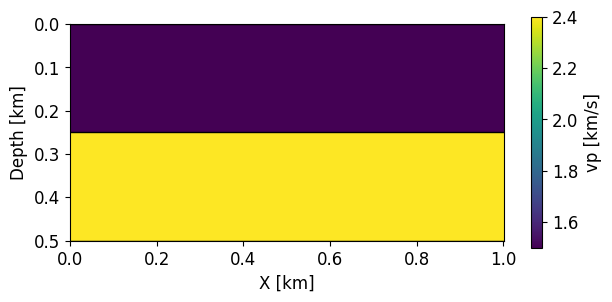

In [3]:
project_25d = fs.Project(
    name="project",
    pretty_name="acoustic_25d",
    path="./scratch/tutorials/acoustic_25d",
    log_level="INFO",
    log_to_console=True,
)
sim_25d = project_25d.new_simulation(
    name="acoustic_25d",
    physics="acoustic",
    dimension="2.5D",
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)
model_25d = add_acoustic_layers(fs.LayeredModel(name="model", dimension="2.5D", x_limits=[0.0, 1.0]))
sim_25d += model_25d
sim_25d += model_25d.hex_mesh_generator([8, 4])
sim_25d.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
add_2d_boundaries(sim_25d)
receiver_coords_25d = add_2d_pressure_line(sim_25d)
sim_25d += fs.Discretization()
sim_25d += fs.SolverConfig(tolerance=1.0e-4, grids=3)

model_25d.plot("vp", figsize=(7, 3), aspect="equal")


## Run And Plot 2.5D Traces

This strict run exercises the 2.5D solver path. If the solver side is not ready, the failure should be visible here and the notebook setup remains inspectable.


In [ ]:
site_25d = fs.Site()
job_25d = fs.TimeDomainJob(
    name="time_25d",
    simulation=sim_25d,
    f_min=0.0,
    f_max=30.0,
    T_max=0.9,
)
result_25d = site_25d.submit(job_25d).wait()
traces_25d = result_25d.traces(upscale=4)
traces_25d.summary


In [ ]:
wavelet = fs.RickerWavelet(f=12.0)
group = traces_25d.groups[0]
component = traces_25d.components(group)[0]
source = traces_25d.sources(group)[0]
gather_25d = traces_25d.td(group, component, source, wavelet, upscale=4, T_max=0.9)
fs.plot_gather(
    gather_25d,
    A=2.0 * np.nanstd(np.real(gather_25d.values)),
    cmap="gray",
    figsize=(9, 4),
    title="2.5D acoustic pressure",
)


## Fixed-Axis 2D Slice In A 3D Coordinate Convention

When a workflow uses 3D coordinates but the solve is a 2D slice, set a global coordinate system with a fixed axis and value. The simulation below is still a 2D x-depth solve, but the coordinate system records that it represents the `y = 0.3 km` slice of a 3D convention. Coordinate systems are covered in more detail in Section 3.2.


In [ ]:
slice_project = fs.Project(name="project", path="./scratch/tutorials/acoustic_fixed_y_slice", log_level="INFO")
sim_slice = slice_project.new_simulation(
    name="acoustic_fixed_y_slice",
    physics="acoustic",
    dimension=2,
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)
sim_slice.global_coordinate_system = fs.CoordinateSystem.cartesian(
    name="global",
    ndim=2,
    fixed_axis="y",
    fixed_value=0.3 * u.km,
)
model_slice = add_acoustic_layers(fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0]))
sim_slice += model_slice
sim_slice += model_slice.hex_mesh_generator([4, 4])
sim_slice += fs.Discretization()
sim_slice.to_fs()["global_coordinate_system"]


## 3D Acoustic Simulation

The 3D run adds `y_limits`, a 3D mesh, and 3D source/receiver coordinates. This example requests a frequency-domain ParaView output so the volume result can be inspected without reconstructing a time-domain gather. A separate local site is created because the earlier strict run shut its worker down after completion.

The ParaView request uses `upscale=0` so the saved screenshot emphasizes the native 3D mesh geometry. Increase `upscale` when field smoothness matters more than file size.


In [ ]:
project_3d = fs.Project(
    name="project",
    pretty_name="acoustic_3d",
    path="./scratch/acoustic_3d",
    log_level="INFO",
    log_to_console=True,
)
sim_3d = project_3d.new_simulation(
    name="acoustic_3d",
    physics="acoustic",
    dimension=3,
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)
model_3d = add_acoustic_layers(
    fs.LayeredModel(name="model", dimension=3, x_limits=[0.0, 1.0], y_limits=[0.0, 0.6])
)
sim_3d += model_3d
sim_3d += model_3d.hex_mesh_generator([6, 4, 4])
sim_3d.mesh.set_adapt(elems_per_wave=2.0, order=3, f_low=5.0, f_high=20.0)
sim_3d += fs.BoundaryCondition(conditions=["free"], boundaries=["z_min"])
sim_3d += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_min", "x_max", "y_min", "y_max", "z_max"],
    pml_wavelengths=0.75,
)

acq_3d = fs.Acquisition()
acq_3d.add_source_group(kind="scalar", coords=[[0.5, 0.3, 0.05]])
hydrophone_3d = fs.ReceiverNode(name="hydrophone")
hydrophone_3d.add_component(name="p", field="pressure")
line_3d = [[x, 0.3, 0.04] for x in np.linspace(0.1, 0.9, 31)]
acq_3d.add_receiver_group(name="centerline", device=hydrophone_3d, coords=line_3d)
sim_3d += acq_3d
sim_3d += fs.Discretization()

site_3d = fs.Site()
job_3d = fs.FrequencyDomainJob(
    name="freq_3d",
    simulation=sim_3d,
    f_list=[15.0],
    outputs=[
        fs.ParaviewOutput(
            name="pv_3d",
            fields=["pressure"],
            properties=["vp", "rho", "Subdomain"],
            show_pml=True,
            upscale=0,
            order=1,
        )
    ],
)
result_3d = site_3d.submit(job_3d).wait()


## Render A 3D Output Screenshot

The screenshot is a lightweight proof that the 3D output exists and can be inspected programmatically. For full 3D interaction, open the `.vtu` files in ParaView.


In [ ]:
vtu_3d = result_3d.output_files(base="pv_3d", suffix=".vtu", existing=True)
image_dir = Path("./assets")
image_dir.mkdir(exist_ok=True)
screenshot = image_dir / "acoustic_3d_vp.png"
fs.plot_vtu(
    vtu_3d[0],
    field="vp",
    show_edges=True,
    scalar_bar=True,
    show=False,
    screenshot=screenshot,
    window_size=(1100, 700),
)
display(Image(filename=str(screenshot)))


## Axisymmetric Acoustic Simulation

Axisymmetric acoustic simulations use a 2D radial-depth model. Here `x` is the radius, the `x_min` boundary is the symmetry axis, and the global coordinate system records the fixed cylindrical angle.


In [ ]:
project_axisym = fs.Project(
    name="project",
    pretty_name="acoustic_axisym",
    path="./scratch/tutorials/acoustic_axisym",
    log_level="INFO",
    log_to_console=True,
)
sim_axisym = project_axisym.new_simulation(
    name="acoustic_axisym",
    physics="acoustic",
    dimension=2,
    axisymmetric=True,
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)
sim_axisym.global_coordinate_system = fs.CoordinateSystem.cylindrical(
    name="global",
    ndim=2,
    fixed_axis="theta",
    fixed_value=0.0,
)
model_axisym = add_acoustic_layers(fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0]))
sim_axisym += model_axisym
sim_axisym += model_axisym.hex_mesh_generator([8, 4])
sim_axisym.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
add_2d_boundaries(sim_axisym, axisymmetric=True)
receiver_coords_axisym = add_2d_pressure_line(sim_axisym, source_x=0.25, source_z=0.05, receiver_z=0.04)
sim_axisym += fs.Discretization()
sim_axisym += fs.SolverConfig(tolerance=1.0e-4, grids=3)

sim_axisym.to_fs()["global_coordinate_system"]


## Run And Plot Axisymmetric Traces

The trace workflow is unchanged, but the geometry interpretation is cylindrical. Comparing this gather with the 2.5D gather helps catch coordinate-system mistakes. A fresh local site is used for the same reason as the 3D section.


In [ ]:
site_axisym = fs.Site()
job_axisym = fs.TimeDomainJob(
    name="time_axisym",
    simulation=sim_axisym,
    f_min=0.0,
    f_max=30.0,
    T_max=0.9,
)
result_axisym = site_axisym.submit(job_axisym).wait()
traces_axisym = result_axisym.traces(upscale=4)
traces_axisym.summary


In [ ]:
group = traces_axisym.groups[0]
component = traces_axisym.components(group)[0]
source = traces_axisym.sources(group)[0]
gather_axisym = traces_axisym.td(group, component, source, wavelet, upscale=4, T_max=0.9)
fs.plot_gather(
    gather_axisym,
    A=2.0 * np.nanstd(np.real(gather_axisym.values)),
    cmap="gray",
    figsize=(9, 4),
    title="Axisymmetric acoustic pressure",
)

fig, ax = plt.subplots(figsize=(8, 3))
trace_25d = gather_25d.isel(receiver=len(gather_25d.receiver) // 2)
trace_axisym = gather_axisym.isel(receiver=len(gather_axisym.receiver) // 2)
ax.plot(trace_25d["time"].values, np.real(trace_25d.values), label="2.5D center receiver")
ax.plot(trace_axisym["time"].values, np.real(trace_axisym.values), label="Axisymmetric center receiver")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure amplitude")
ax.legend()
ax.set_title("Geometry-mode response comparison")


## Result Review Checklist

This notebook compares geometry modes, so the final review should separate API sameness from physics interpretation. The trace-reading API is intentionally similar across modes, but the coordinate meaning is not.

| Mode | What should stay familiar | What changes physically |
| --- | --- | --- |
| 2.5D | 2D model, receiver groups, `TraceDataset` reads | Out-of-plane propagation effects are included by the formulation. |
| Fixed-axis 2D slice | 2D solve and mesh | Coordinates record the slice location inside a 3D convention. |
| 3D | Same job/site/output lifecycle | Source, receivers, mesh, and ParaView output use full 3D coordinates. |
| Axisymmetric | Same trace workflow | `x` is radial distance and `x_min` is the symmetry axis. |

When results differ, check the coordinate-system payload before changing material properties. Geometry-mode mistakes often look like amplitude or timing problems until the coordinate convention is inspected.
